# Data preprocessing

### Importing necessary for EDA

In [1]:
# Importing necessary libraries 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Importing the data set

In [2]:
# Importing the data set

df = pd.read_csv(r"G:\data_analytics_and_genAI\Assignment\Assignment-Logistic_regression\Lead-Scoring-Assignment\Leads.csv")

### Summarizing the data set

In [3]:
# First five rows of the data set
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [4]:
# Checking data types of the columns
df.dtypes

Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                            object
Magazine                       

In [5]:
# Checking shape of the data set
print(f'The shape of dataset is: {df.shape}')

The shape of dataset is: (9240, 37)


In [6]:
# Creating a list of columns
column = df.columns

print('The columns in dataset are\n',column)

The columns in dataset are
 Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
     

In [7]:
# Checking another value count of all the null values in the columns with percentage.
null_values_count = df.isnull().sum()
null_values_count = pd.DataFrame(null_values_count, columns=['Null Values Count'])
null_values_count = null_values_count[null_values_count['Null Values Count'] > 0]

null_values_count['Percentage of Null Values'] = ((null_values_count['Null Values Count'] / df.shape[0]) * 100).round(2)
null_values_count = null_values_count.sort_values(by='Null Values Count', ascending=False)
display(null_values_count)

,Null Values Count,Percentage of Null Values
Lead Quality,4767,51.59
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Index,4218,45.65
Asymmetrique Activity Score,4218,45.65
Asymmetrique Profile Index,4218,45.65
Tags,3353,36.29
What matters most to you in choosing a course,2709,29.32
Lead Profile,2709,29.32
What is your current occupation,2690,29.11
Country,2461,26.63


In [8]:
# Check for duplicate values in the data set

print('The duplicates in the data sets are',df.duplicated().sum())

The duplicates in the data sets are 0


In [9]:
# Checking number of unique Variables in the columns

for col in column:
    print(f'The unique object in column {col} are :{df[col].nunique()}')


The unique object in column Prospect ID are :9240
The unique object in column Lead Number are :9240
The unique object in column Lead Origin are :5
The unique object in column Lead Source are :21
The unique object in column Do Not Email are :2
The unique object in column Do Not Call are :2
The unique object in column Converted are :2
The unique object in column TotalVisits are :41
The unique object in column Total Time Spent on Website are :1731
The unique object in column Page Views Per Visit are :114
The unique object in column Last Activity are :17
The unique object in column Country are :38
The unique object in column Specialization are :19
The unique object in column How did you hear about X Education are :10
The unique object in column What is your current occupation are :6
The unique object in column What matters most to you in choosing a course are :3
The unique object in column Search are :2
The unique object in column Magazine are :1
The unique object in column Newspaper Artic

### Creating a list of columns with their categories

#### Binary Columns

In [10]:
# Identifying the binary columns in the data set
binary_col = []
for col in column:
    if df[col].nunique() <= 2:
        binary_col.append(col)
        
print(f'The binary columns are: {binary_col}')

The binary columns are: ['Do Not Email', 'Do Not Call', 'Converted', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview']


In [11]:
# Converting the binary columns to boolean data type. As boolean data is more easy to feed the machine learning than categorical.
for col in binary_col:
    df[col] = df[col].astype(bool)

In [12]:
# Checking the data types and first five rows of the data set after converting the binary columns to boolean data type
display(df.dtypes)
display(df.head())

Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                        bool
Do Not Call                                         bool
Converted                                           bool
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                              bool
Magazine                       

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,True,True,False,0.0,0,0.0,...,True,Select,Select,02.Medium,02.Medium,15.0,15.0,True,True,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,True,True,False,5.0,674,2.5,...,True,Select,Select,02.Medium,02.Medium,15.0,15.0,True,True,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,True,True,True,2.0,1532,2.0,...,True,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,True,True,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,True,True,False,1.0,305,1.0,...,True,Select,Mumbai,02.Medium,01.High,13.0,17.0,True,True,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,True,True,True,2.0,1428,1.0,...,True,Select,Mumbai,02.Medium,01.High,15.0,18.0,True,True,Modified


#### Object Columns

In [13]:
# Creating list object columns
object_col = []
for col in column:
    if df[col].dtype == 'object':
        object_col.append(col)

print(f'The object columns are: {object_col}')

The object columns are: ['Prospect ID', 'Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Tags', 'Lead Quality', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Last Notable Activity']


#### Numeric Columns

In [14]:
# Making a list of numeric columns
numeric_col = []
for col in column:
    if df[col].dtype in ['int64', 'float64']:
        numeric_col.append(col)

numeric_col.remove('Lead Number')
print(f'The numeric columns are: {numeric_col}')

The numeric columns are: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']


#### Categorical columns

In [15]:
#Creating list of categorical columns
categorical_col = object_col

# Removing unnecessary columns name from categorical_col list
categorical_col.remove('Prospect ID')
# Checking the changes
print(categorical_col)

['Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Tags', 'Lead Quality', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Last Notable Activity']


### Missing values treatment

In [16]:
# replacing select with nan

for col in categorical_col:
    df[col] = df[col].str.strip().replace({'Select': np.nan})

In [17]:
# Checking another value count of all the columns with percentage After replacing select with null values.
null_values_count = df.isnull().sum()
null_values_count = pd.DataFrame(null_values_count, columns=['Null Values Count'])
null_values_count = null_values_count[null_values_count['Null Values Count'] > 0]

null_values_count['Percentage of Null Values'] = ((null_values_count['Null Values Count'] / df.shape[0]) * 100).round(2)
null_values_count = null_values_count.sort_values(by='Null Values Count', ascending=False)
display(null_values_count)

,Null Values Count,Percentage of Null Values
How did you hear about X Education,7250,78.46
Lead Profile,6855,74.19
Lead Quality,4767,51.59
Asymmetrique Activity Index,4218,45.65
Asymmetrique Profile Index,4218,45.65
Asymmetrique Profile Score,4218,45.65
Asymmetrique Activity Score,4218,45.65
City,3669,39.71
Specialization,3380,36.58
Tags,3353,36.29


There are huge amount of missing value in few columns those are better to drop.

In [18]:
# Dropping columns with high missing values
df.drop(columns= 'How did you hear about X Education', inplace=True)
df.drop(columns= 'Lead Profile', inplace=True)
df.drop(columns= 'Lead Quality', inplace=True)
df.drop(columns= 'Asymmetrique Activity Index', inplace=True)
df.drop(columns= 'Asymmetrique Profile Index', inplace=True)
df.drop(columns= 'Asymmetrique Profile Score', inplace=True)
df.drop(columns= 'Asymmetrique Activity Score', inplace=True)



# Removing the dropped columns from the categorical columns list
categorical_col.remove('How did you hear about X Education')
categorical_col.remove('Lead Profile')
categorical_col.remove('Lead Quality')
categorical_col.remove('Asymmetrique Activity Index')
categorical_col.remove('Asymmetrique Profile Index')
numeric_col.remove('Asymmetrique Profile Score')
numeric_col.remove('Asymmetrique Activity Score')


In [19]:
# Finding Count of the city.
print(df.groupby('City').size().sort_values(ascending=False))
print(f"missing values in city columns are {df['City'].isnull().sum()}")

City
Mumbai                         3222
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
dtype: int64
missing values in city columns are 3669


In [20]:
#Finding Count of the country. 
print(df.groupby('Country').size().sort_values(ascending= False))
print(f"missing values in city coluns are {df['Country'].isnull().sum()}")

Country
India                   6492
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Bahrain                    7
Hong Kong                  7
France                     6
Oman                       6
unknown                    5
Canada                     4
Kuwait                     4
Nigeria                    4
Germany                    4
South Africa               4
Sweden                     3
Belgium                    2
Asia/Pacific Region        2
Bangladesh                 2
Ghana                      2
Uganda                     2
Philippines                2
Netherlands                2
Italy                      2
China                      2
Denmark                    1
Indonesia                  1
Malaysia                   1
Liberia                    1
Kenya                      1
Russia                     1
Sri La

In [21]:
# Where countries equal to unknown and Asia/Pacific Region we are replacing with it null value 
df['Country'].str.strip().replace({'unknown': np.nan}, inplace=True)
df['Country'] = df['Country'].replace('Asia/Pacific Region', np.nan)


In [22]:
# filling the missing values in the country column with India where the city is Mumbai, Thane & Outskirts, Other Cities of Maharashtra
df.loc[df['City'].isin(['Mumbai', 'Thane & Outskirts', 'Other Cities of Maharashtra']), 'Country'] = df.loc[df['City'].isin(['Mumbai', 'Thane & Outskirts', 'Other Cities of Maharashtra']), 'Country'].fillna('India')
# The linked value of city where country is equal to India to other cities of India
df.loc[df['Country'] == 'India', 'City'] =df.loc[df['Country'] == 'India', 'City'].fillna('Other Cities of India')

In [23]:
# Checking missing value once again 
display(df.isnull().sum().sort_values(ascending=False))

Specialization                                   3380
Tags                                             3353
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2129
City                                             2115
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
Prospect ID                                         0
Do Not Call                                         0
Lead Origin                                         0
Lead Number                                         0
Converted                                           0
Total Time Spent on Website                         0
Do Not Email                                        0
Search                                              0
X Education Forums          

In [24]:
# Checking the unique values in the tags column
df['Tags'].unique()

array(['Interested in other courses', 'Ringing',
       'Will revert after reading the email', nan, 'Lost to EINS',
       'In confusion whether part time or DLP', 'Busy', 'switched off',
       'in touch with EINS', 'Already a student',
       'Diploma holder (Not Eligible)', 'Graduation in progress',
       'Closed by Horizzon', 'number not provided', 'opp hangup',
       'Not doing further education', 'invalid number',
       'wrong number given', 'Interested  in full time MBA',
       'Still Thinking', 'Lost to Others',
       'Shall take in the next coming month', 'Lateral student',
       'Interested in Next batch', 'Recognition issue (DEC approval)',
       'Want to take admission but has financial problems',
       'University not recognized'], dtype=object)

In [25]:
# Replacing similar keywords With single word.
df['Tags'] = df['Tags'].str.strip().replace({'Diploma holder (Not Eligible)': 'Not Eligible','University not recognized':'Not Eligible'})

df['Tags'] = df['Tags'].str.strip().replace({'wrong number given','invalid number','opp hangup','number not provided'},'not interested')

In [26]:
# Describing the data set.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead Number,9240.0,617188.435606,23405.995698,579533.0,596484.5,615479.0,637387.25,660737.0
TotalVisits,9103.0,3.445238,4.854853,0.0,1.0,3.0,5.00,251.0
Total Time Spent on Website,9240.0,487.698268,548.021466,0.0,12.0,248.0,936.00,2272.0
Page Views Per Visit,9103.0,2.362820,2.161418,0.0,1.0,2.0,3.00,55.0


In [27]:
# Checking the 
for col in categorical_col:
    print(f'The unique object in column {col} are :{df[col].unique()}')

The unique object in column Lead Origin are :['API' 'Landing Page Submission' 'Lead Add Form' 'Lead Import'
 'Quick Add Form']
The unique object in column Lead Source are :['Olark Chat' 'Organic Search' 'Direct Traffic' 'Google' 'Referral Sites'
 'Welingak Website' 'Reference' 'google' 'Facebook' nan 'blog'
 'Pay per Click Ads' 'bing' 'Social Media' 'WeLearn' 'Click2call'
 'Live Chat' 'welearnblog_Home' 'youtubechannel' 'testone' 'Press_Release'
 'NC_EDM']
The unique object in column Last Activity are :['Page Visited on Website' 'Email Opened' 'Unreachable'
 'Converted to Lead' 'Olark Chat Conversation' 'Email Bounced'
 'Email Link Clicked' 'Form Submitted on Website' 'Unsubscribed'
 'Had a Phone Conversation' 'View in browser link Clicked' nan
 'Approached upfront' 'SMS Sent' 'Visited Booth in Tradeshow'
 'Resubscribed to emails' 'Email Received' 'Email Marked Spam']
The unique object in column Country are :[nan 'India' 'Russia' 'Kuwait' 'Oman' 'United Arab Emirates'
 'United States' 

In [28]:
# Standardizing the columns
df['Lead Source'] = df['Lead Source'].str.strip().replace({'google': 'Google'})

In [29]:
for col in categorical_col:
    print(f'The unique object in column {col} are :{df[col].unique()}')

The unique object in column Lead Origin are :['API' 'Landing Page Submission' 'Lead Add Form' 'Lead Import'
 'Quick Add Form']
The unique object in column Lead Source are :['Olark Chat' 'Organic Search' 'Direct Traffic' 'Google' 'Referral Sites'
 'Welingak Website' 'Reference' 'Facebook' nan 'blog' 'Pay per Click Ads'
 'bing' 'Social Media' 'WeLearn' 'Click2call' 'Live Chat'
 'welearnblog_Home' 'youtubechannel' 'testone' 'Press_Release' 'NC_EDM']
The unique object in column Last Activity are :['Page Visited on Website' 'Email Opened' 'Unreachable'
 'Converted to Lead' 'Olark Chat Conversation' 'Email Bounced'
 'Email Link Clicked' 'Form Submitted on Website' 'Unsubscribed'
 'Had a Phone Conversation' 'View in browser link Clicked' nan
 'Approached upfront' 'SMS Sent' 'Visited Booth in Tradeshow'
 'Resubscribed to emails' 'Email Received' 'Email Marked Spam']
The unique object in column Country are :[nan 'India' 'Russia' 'Kuwait' 'Oman' 'United Arab Emirates'
 'United States' 'Australia

In [30]:
# droping rows with more than 80% missing value
df = df.dropna(thresh= df.shape[1]* 0.2)

In [31]:
df.isnull().sum().sort_values(ascending=False)

Specialization                                   3380
Tags                                             3353
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2129
City                                             2115
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
Prospect ID                                         0
Do Not Call                                         0
Lead Origin                                         0
Lead Number                                         0
Converted                                           0
Total Time Spent on Website                         0
Do Not Email                                        0
Search                                              0
X Education Forums          

In [32]:
df['Lead Source'].fillna('Others', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\686448753.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Lead Source'].fillna('Others', inplace=True)


In [33]:
df['Last Activity'].fillna('Unknown', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\2402765046.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last Activity'].fillna('Unknown', inplace=True)


In [34]:
df[['Page Views Per Visit', 'TotalVisits']] = df[['Page Views Per Visit', 'TotalVisits']].fillna(0)

In [35]:
df['Specialization'].fillna('Other_Specializations', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\3608689571.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Specialization'].fillna('Other_Specializations', inplace=True)


In [36]:
df['City'].fillna('Other Cities', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\2128414777.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].fillna('Other Cities', inplace=True)


In [37]:
df['Country'].fillna('India', inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_30084\266071714.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna('India', inplace=True)


In [38]:
df['What is your current occupation'].fillna('Not Specified', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\685281539.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['What is your current occupation'].fillna('Not Specified', inplace=True)


In [39]:
df['What matters most to you in choosing a course'].fillna(df['What matters most to you in choosing a course'].mode()[0], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\2651780220.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['What matters most to you in choosing a course'].fillna(df['What matters most to you in choosing a course'].mode()[0], inplace=True)


In [40]:
df['Tags'].fillna('Unknown', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30084\789586320.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tags'].fillna('Unknown', inplace=True)


In [41]:
df.isnull().sum().sort_values(ascending=False)

Prospect ID                                      0
Lead Number                                      0
Lead Origin                                      0
Lead Source                                      0
Do Not Email                                     0
Do Not Call                                      0
Converted                                        0
TotalVisits                                      0
Total Time Spent on Website                      0
Page Views Per Visit                             0
Last Activity                                    0
Country                                          0
Specialization                                   0
What is your current occupation                  0
What matters most to you in choosing a course    0
Search                                           0
Magazine                                         0
Newspaper Article                                0
X Education Forums                               0
Newspaper                      

### Cleaning datedet

In [42]:
df.groupby('Lead Source').size().sort_values(ascending=False)

Lead Source
Google               2873
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
Others                 36
bing                    6
Click2call              4
Live Chat               2
Press_Release           2
Social Media            2
NC_EDM                  1
Pay per Click Ads       1
WeLearn                 1
blog                    1
testone                 1
welearnblog_Home        1
youtubechannel          1
dtype: int64

In [43]:
# Replacing unpopular sources that has less than 5 count with 'others'
rare_sources = df['Lead Source'].value_counts()
rare_sources = rare_sources[rare_sources < 5].index
df['Lead Source'] = df['Lead Source'].replace(rare_sources, 'Others')

In [44]:
column = df.columns
for col in column:
    print("Number of unique values in column {} are: {}".format(col, df[col].nunique()))

Number of unique values in column Prospect ID are: 9240
Number of unique values in column Lead Number are: 9240
Number of unique values in column Lead Origin are: 5
Number of unique values in column Lead Source are: 10
Number of unique values in column Do Not Email are: 1
Number of unique values in column Do Not Call are: 1
Number of unique values in column Converted are: 2
Number of unique values in column TotalVisits are: 41
Number of unique values in column Total Time Spent on Website are: 1731
Number of unique values in column Page Views Per Visit are: 114
Number of unique values in column Last Activity are: 18
Number of unique values in column Country are: 37
Number of unique values in column Specialization are: 19
Number of unique values in column What is your current occupation are: 7
Number of unique values in column What matters most to you in choosing a course are: 3
Number of unique values in column Search are: 1
Number of unique values in column Magazine are: 1
Number of un

In [45]:
df.columns

Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [46]:
# droping columns with only one unique value as they are not useful for analysis
column = df.columns
for col in column:
    nunique_values = df[col].nunique()
    if nunique_values == 1:
        df = df.drop(columns= col)

column = df.columns
print(f'The columns in dataset are\n {column}')

The columns in dataset are
 Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Converted',
       'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit',
       'Last Activity', 'Country', 'Specialization',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Tags', 'City',
       'Last Notable Activity'],
      dtype='object')


### Managing Outlier 

In [47]:

before_shape = df.shape
numeric_col = df.select_dtypes(include=['int64', 'float64']).columns.tolist()   
# Start with a mask that keeps all rows initially
mask = pd.Series(True, index=df.index)

for col in numeric_col:
    # Calculate the 1st and 3rd quartiles for the numeric column
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Keep rows that are within bounds or have missing values for this column
    mask &= (df[col].between(lower, upper) | df[col].isna())

# Apply the combined mask and reset the index after removing outlier rows
df = df.loc[mask].reset_index(drop=True)

print(f"Shape before outlier removal: {before_shape}")
print(f"Shape after outlier removal: {df.shape}")

Shape before outlier removal: (9240, 16)
Shape after outlier removal: (8844, 16)


# EDA

### Univarieties analysis

In [48]:
# Checking conversion rate
conversion_rate = df['Converted'].mean() * 100
print(f"The conversion rate(After outlier removal) is: {conversion_rate:.2f}%")

The conversion rate(After outlier removal) is: 38.36%


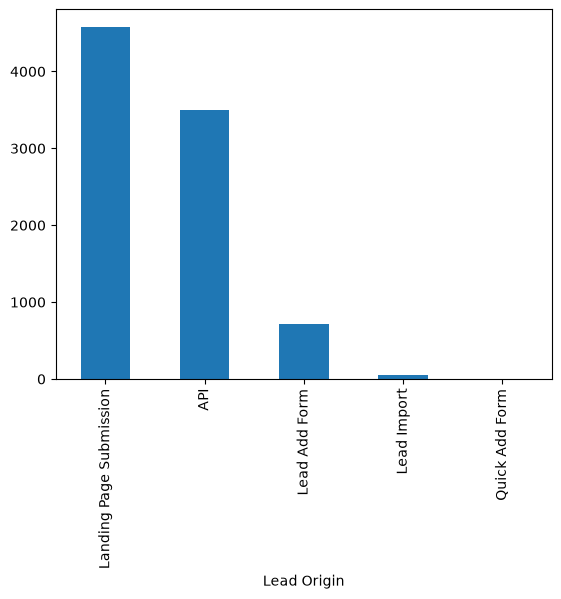

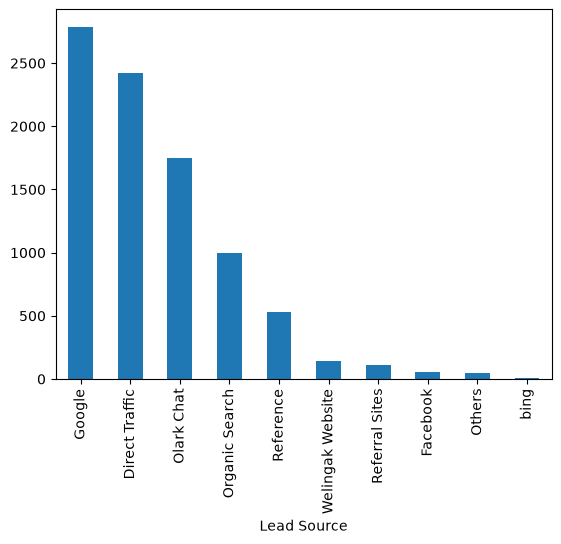

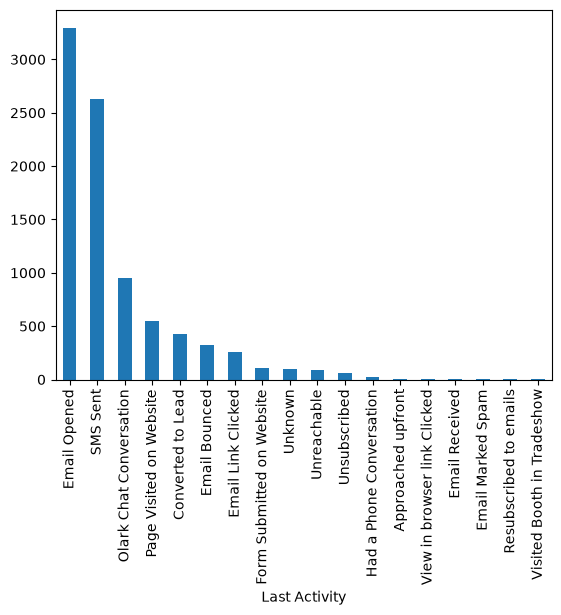

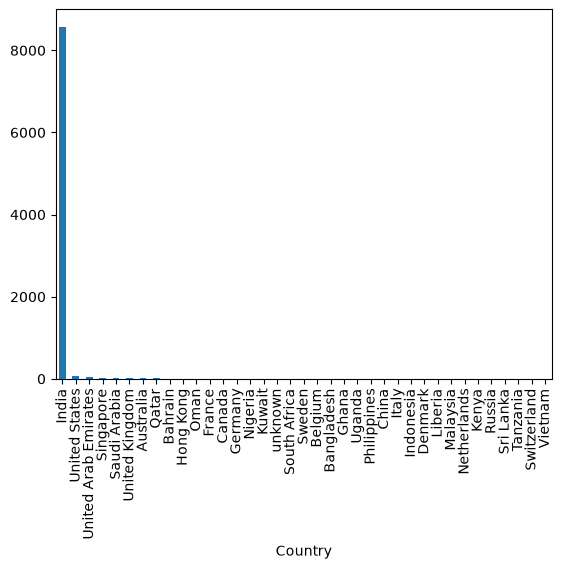

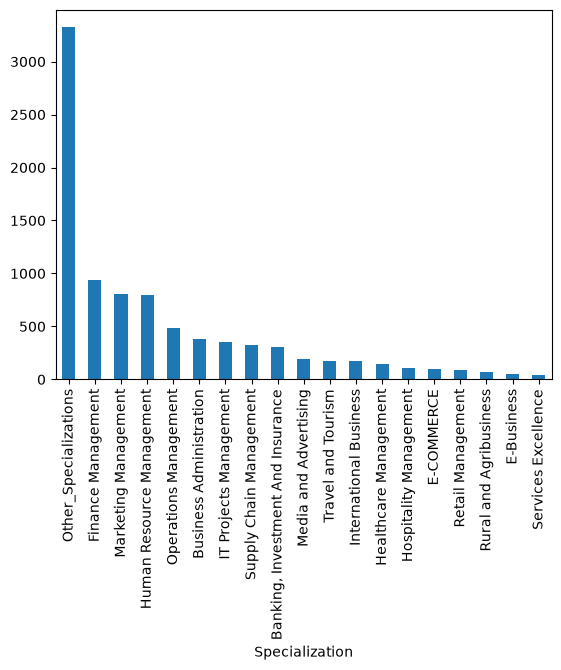

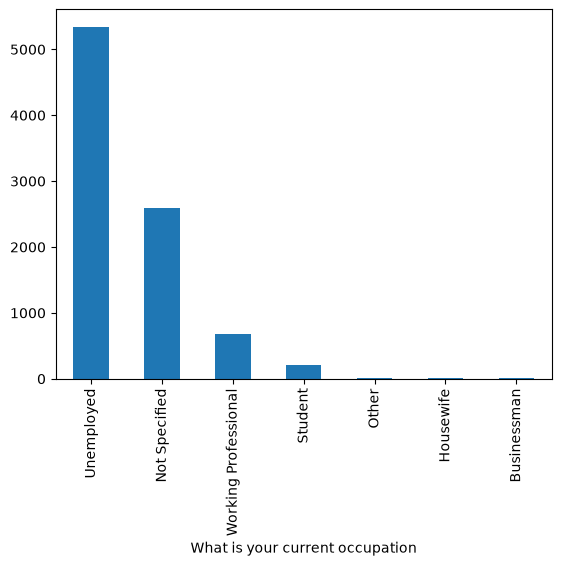

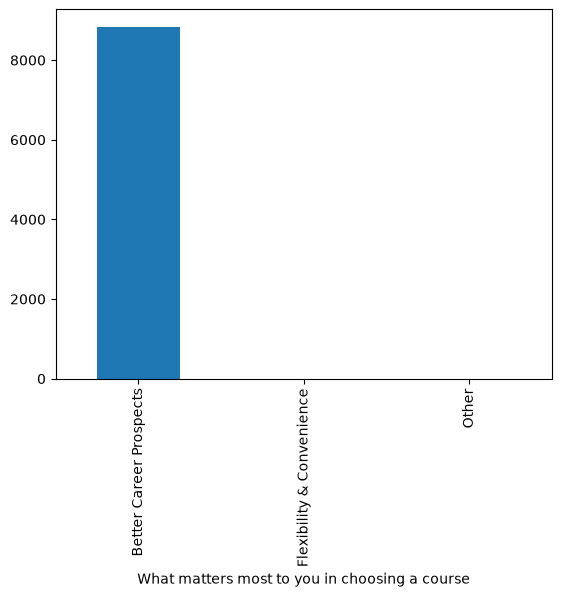

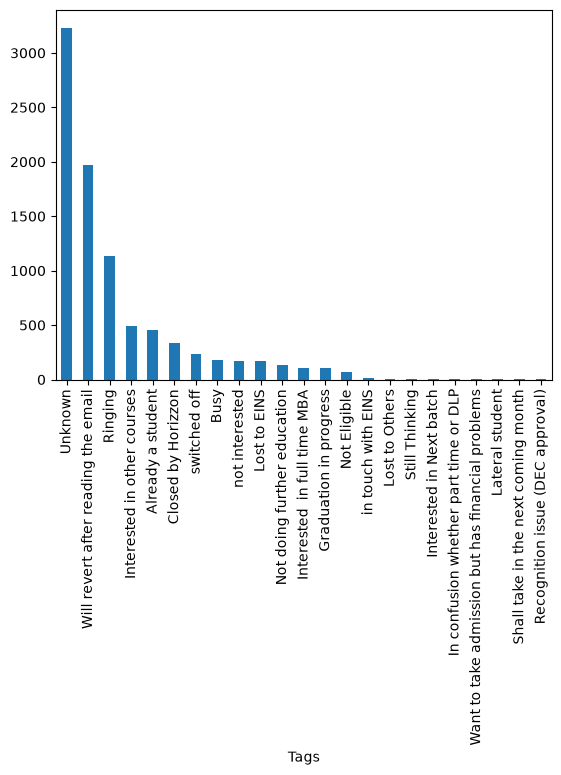

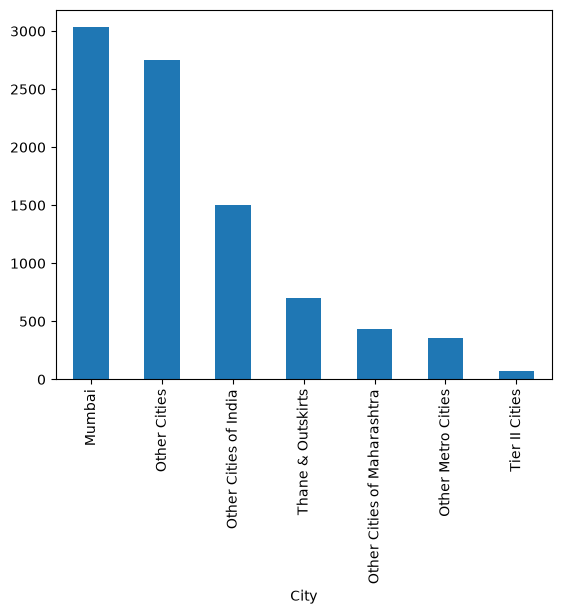

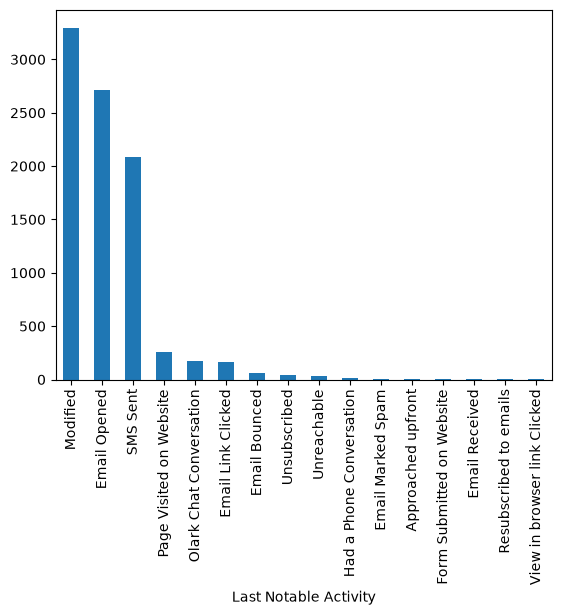

In [49]:
# Creating a bar plot on all the categorical columns
for col in categorical_col :
    df.groupby(col).size().sort_values(ascending=False).plot(kind= 'bar')
    plt.show()

### Bivariate analysis

In [50]:
# Checking the aggrigation of numeric columns for each category of target variable by conversion
for col in numeric_col :
    print(f'The mean of {col} for each category of Converted is :')
    display(df.groupby('Converted')[col].agg(['mean', 'min', 'max', 'median']))

The mean of Lead Number for each category of Converted is :


,mean,min,max,median
Converted,,,,
False,616689.688131,579545,660737,614268.0
True,618030.623637,579533,660727,617228.0


The mean of TotalVisits for each category of Converted is :


,mean,min,max,median
Converted,,,,
False,2.807925,0.0,12.0,2.0
True,2.964338,0.0,12.0,3.0


The mean of Total Time Spent on Website for each category of Converted is :


,mean,min,max,median
Converted,,,,
False,326.557145,0,2272,175.0
True,722.729148,0,2253,804.0


The mean of Page Views Per Visit for each category of Converted is :


,mean,min,max,median
Converted,,,,
False,2.148855,0.0,7.0,2.0
True,2.078179,0.0,7.0,2.0


From the above analysis we can find out that more the total time spent on website The more the chances of the learner will get converted.

C:\Users\User\AppData\Local\Temp\ipykernel_30084\1330641016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data= df, x= 'Converted', y= col, palette= 'Set1')


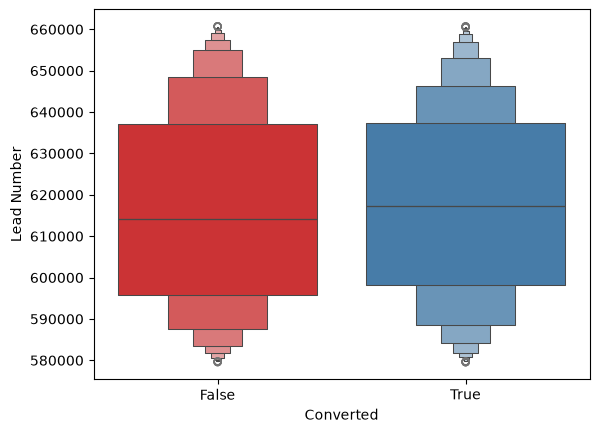

C:\Users\User\AppData\Local\Temp\ipykernel_30084\1330641016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data= df, x= 'Converted', y= col, palette= 'Set1')


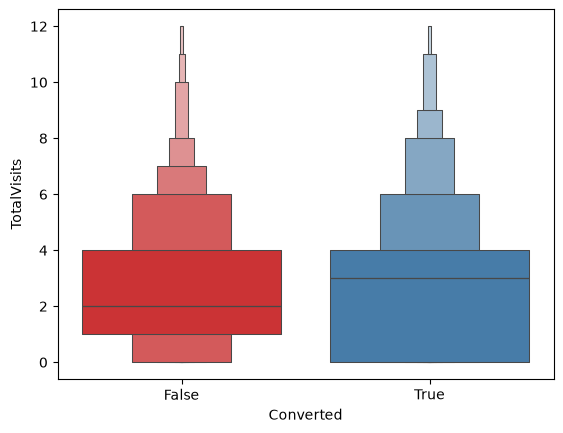

C:\Users\User\AppData\Local\Temp\ipykernel_30084\1330641016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data= df, x= 'Converted', y= col, palette= 'Set1')


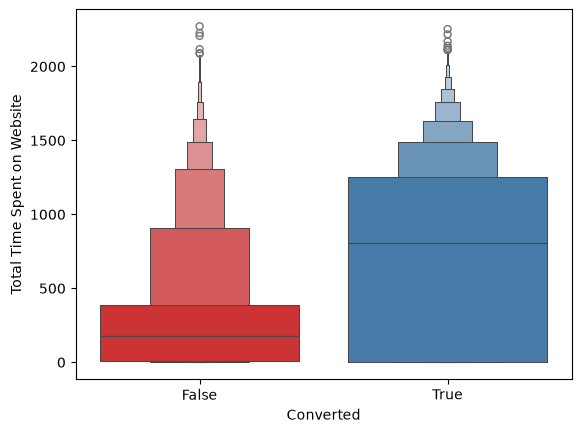

C:\Users\User\AppData\Local\Temp\ipykernel_30084\1330641016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data= df, x= 'Converted', y= col, palette= 'Set1')


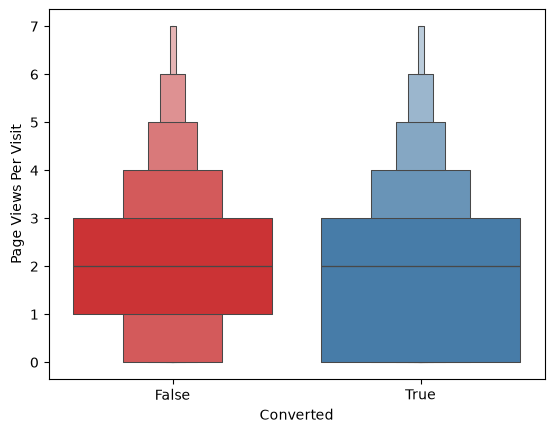

In [51]:
for col in numeric_col:
    sns.boxenplot(data= df, x= 'Converted', y= col, palette= 'Set1')
    plt.show()

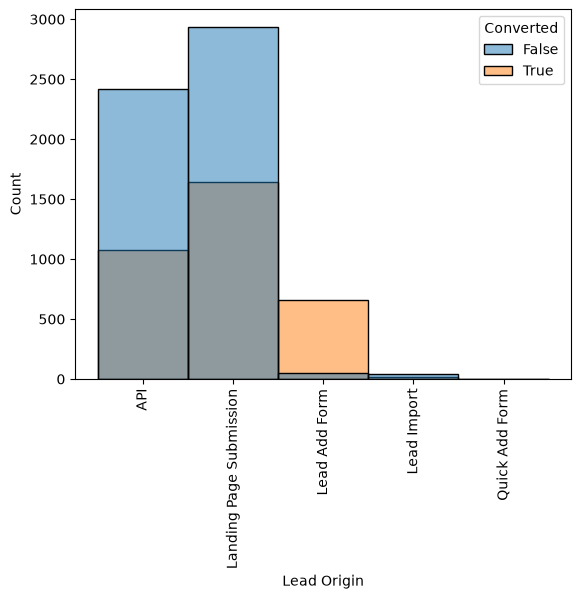

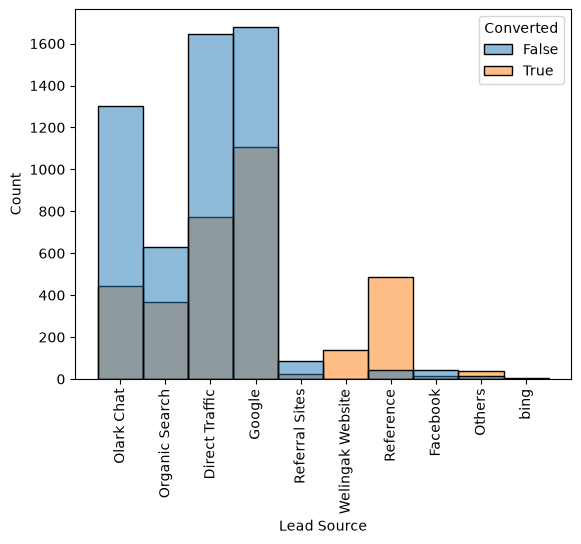

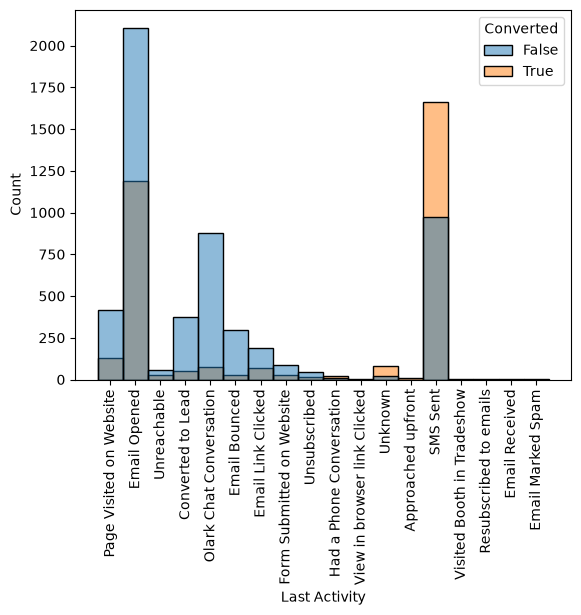

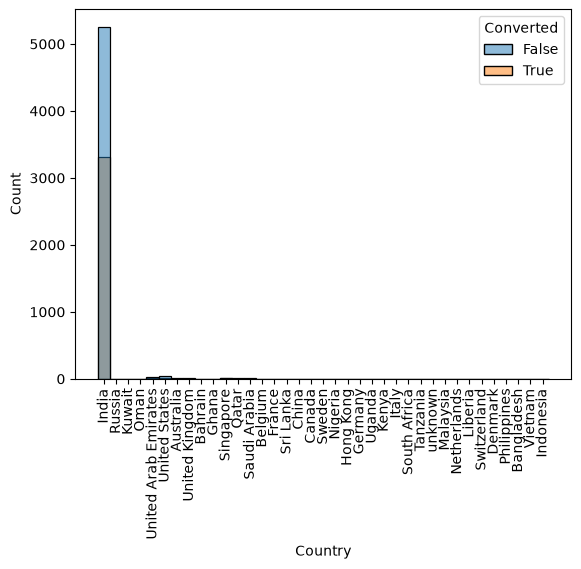

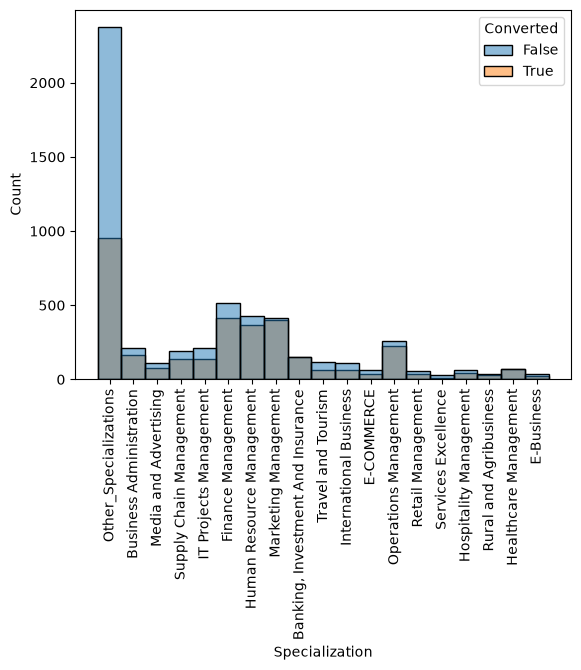

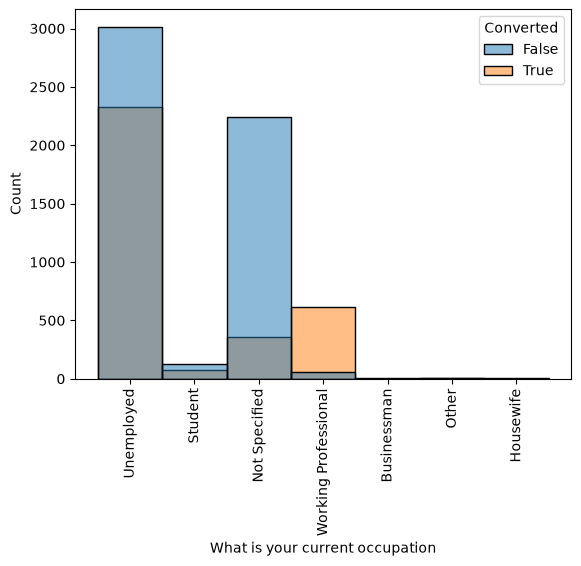

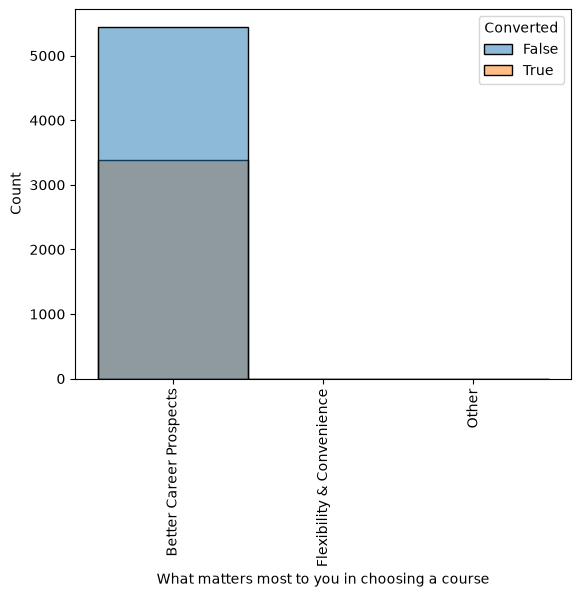

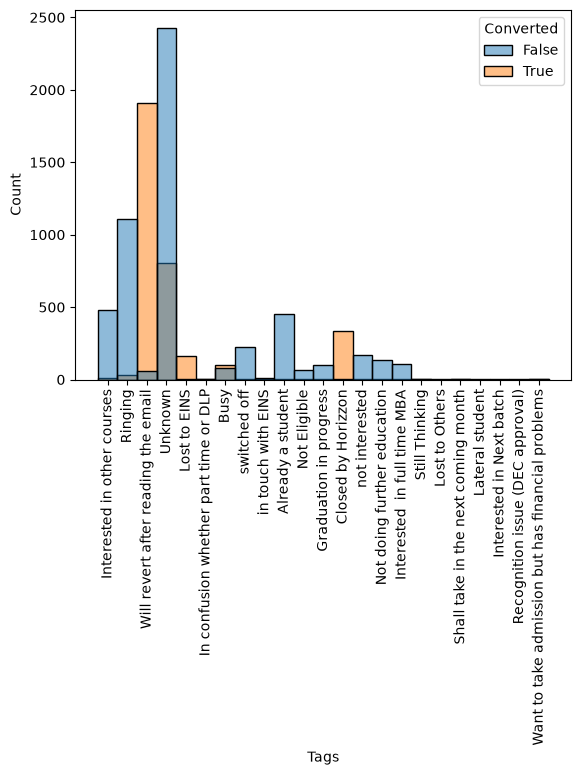

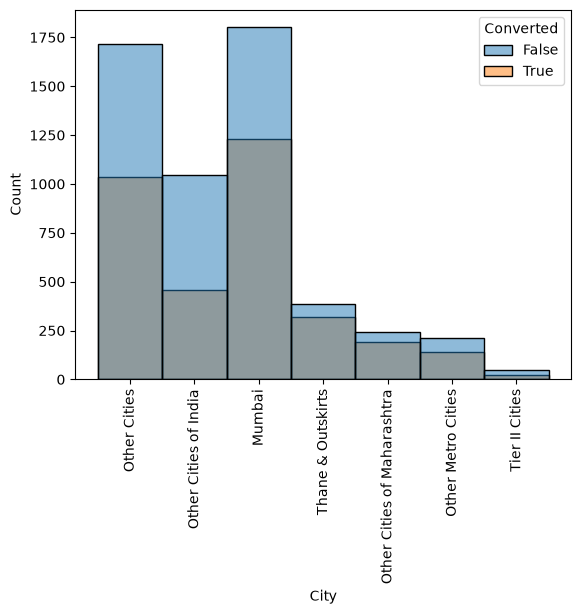

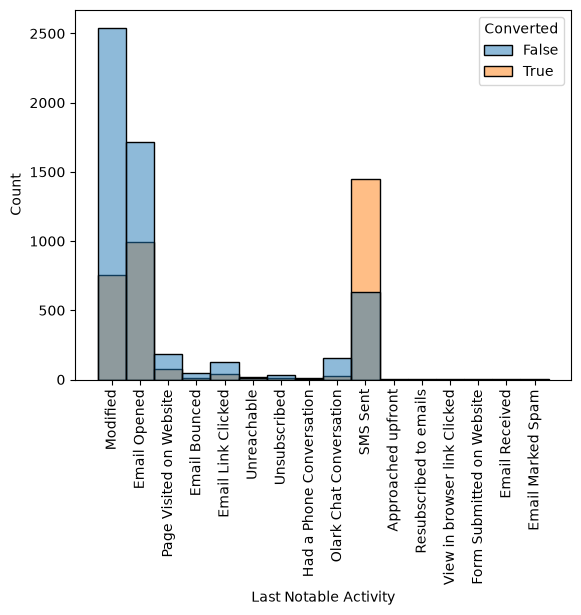

In [52]:
# Ploting the categorical columns in hist plot by bar graph
for col in categorical_col:
    sns.histplot(data= df, x= col,hue= 'Converted') 
    plt.xticks(rotation=90)
    plt.show()

### Multivariate analysis


<Axes: >

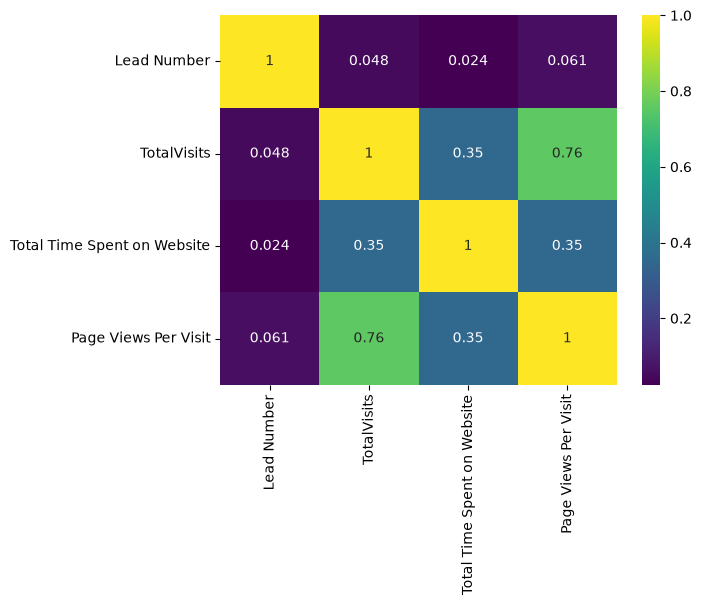

In [53]:
sns.heatmap(data= df[numeric_col].corr(), annot= True, cmap= 'viridis')

# Data Cleaning for machine learning model

In [54]:
# Data Cleaning for machine learning model

In [55]:
# creating a copy of the dataset
ml_df = df.copy()
# Droping unnecessary columns
ml_df.drop(['Lead Number', 'Prospect ID'], axis=1, inplace=True)


###  Importing necessary libraries for machine learning model

In [56]:
# Importing necessary libraries for machine learning model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [57]:
# One-hot encode categorical columns 
ml_df = pd.get_dummies(ml_df, columns=categorical_col, drop_first=True)

### Scaling the numeric data

In [58]:
# Creating a copy
ml_df_scaled = ml_df.copy()

In [59]:
numeric_col = ml_df_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [60]:
# creating base model for machine learning
model = LogisticRegression()
# Hitting the data in 70-30 proportion
xtrain, xtest, ytrain, ytest = train_test_split(ml_df_scaled.drop('Converted', axis=1), ml_df['Converted'], test_size=0.3, random_state=42)


In [61]:
# Scaling the data set
scaler = StandardScaler()
xtrain[numeric_col]  = scaler.fit_transform(xtrain[numeric_col])
xtest[numeric_col]  = scaler.transform(xtest[numeric_col])
# Checking first five roes of dataset
xtrain.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
7759,0.827876,1.364547,1.631170,True,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
6566,0.434557,-0.174834,1.060386,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
7917,0.827876,-0.781810,0.204210,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1539,-1.138719,-0.884192,-1.222751,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
6961,-1.138719,-0.884192,-1.222751,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False


# Machine Learing


### Base model

In [62]:
# Running a model
model.fit(xtrain, ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [63]:
# Predicting the model

model.predict(xtest)

array([ True, False,  True, ...,  True, False, False], shape=(2654,))

In [64]:
# Checking accuracy of the model On the test and train data. 
accuracy = accuracy_score(ytest, model.predict(xtest))# Test accuracy
print(f"The accuracy of the model is: {accuracy:.4f}")
accuracy_train = accuracy_score(ytrain, model.predict(xtrain))# Train accuracy 
print(f"The accuracy of the model on the training set is: {accuracy_train:.4f}")



# Building a classification report on test and train data
# Classification report gives precision, recall, f1-score, support
y_pred_test = model.predict(xtest)
report = classification_report(ytest, y_pred_test)
print("Classification Report of test data:\n")
print(report)

# Classification report gives precision, recall, f1-score, support
y_pred_train = model.predict(xtrain)
report = classification_report(ytrain, y_pred_train)
print("Classification Report of train data:\n")
print(report)


The accuracy of the model is: 0.9344
The accuracy of the model on the training set is: 0.9449
Classification Report of test data:

              precision    recall  f1-score   support

       False       0.94      0.95      0.95      1656
        True       0.92      0.90      0.91       998

    accuracy                           0.93      2654
   macro avg       0.93      0.93      0.93      2654
weighted avg       0.93      0.93      0.93      2654

Classification Report of train data:

              precision    recall  f1-score   support

       False       0.95      0.96      0.96      3795
        True       0.94      0.92      0.93      2395

    accuracy                           0.94      6190
   macro avg       0.94      0.94      0.94      6190
weighted avg       0.94      0.94      0.94      6190



In [65]:

# Confusion Matrix for test data
cm = confusion_matrix(ytest, y_pred_test)
print("Confusion Matrix:\n", cm)

# Confusion Matrix for train data
cm = confusion_matrix(ytrain, y_pred_train)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[1580   76]
 [  98  900]]
Confusion Matrix:
 [[3652  143]
 [ 198 2197]]


### Feature selection for the model 

#### RFE feature selection

In [66]:
#importing necessary libraries for RFE

from sklearn.feature_selection import RFE

In [67]:
# Using RFE for feature selection. Selecting top 15 features
selector = RFE(estimator=model, n_features_to_select=15)

X = ml_df_scaled.drop('Converted', axis=1)# Predicting variables 
y = ml_df_scaled['Converted']# Target variables
# Applying electron data set
selector.fit(X, y)



c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",15
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[bool](2,)","[False, True]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LogisticRegression,LogisticRegression()
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](138,)","['TotalVisits','Total Time Spent on Website','Page Views Per Visit',..., 'Last Notable Activity_Unreachable','Last Notable Activity_Unsubscribed', 'Last Notable Activity_View in browser link Clicked']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(15)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,138


In [68]:
# Selecting the features that are selected by RFE
selected_features = X.columns[selector.support_].tolist()
print(f'The selected features are: {selected_features}')

The selected features are: ['Lead Source_Welingak Website', 'Last Activity_Email Bounced', 'Last Activity_Olark Chat Conversation', 'What is your current occupation_Not Specified', 'Tags_Busy', 'Tags_Closed by Horizzon', 'Tags_Interested in Next batch', 'Tags_Lateral student', 'Tags_Lost to EINS', 'Tags_Ringing', 'Tags_Unknown', 'Tags_Will revert after reading the email', 'Tags_not interested', 'Tags_switched off', 'Last Notable Activity_SMS Sent']


In [69]:
# Checking ranking of each feature

ranking = pd.Series(selector.ranking_, index=X.columns).sort_values()
ranking_df = pd.DataFrame({'Feature': X.columns, 'Ranking': selector.ranking_}).sort_values(by='Ranking')
pd.set_option('display.max_rows', None)  # Show all rows
# Checking ranking of top 15 features
display(ranking_df.head(15))




,Feature,Ranking
14,Lead Source_Welingak Website,1
17,Last Activity_Email Bounced,1
24,Last Activity_Olark Chat Conversation,1
100,Tags_Interested in Next batch,1
108,Tags_Ringing,1
96,Tags_Closed by Horizzon,1
115,Tags_not interested,1
113,Tags_Will revert after reading the email,1
116,Tags_switched off,1
103,Tags_Lost to EINS,1


In [70]:
# New rfe selected data 
ml_df_rfe_selected = ml_df_scaled[selected_features + ['Converted']]


#### Testing model after RFE

In [71]:
X = ml_df_rfe_selected.drop('Converted', axis=1)# predictors variable
y = ml_df_rfe_selected['Converted']# Target variable

In [72]:
# Splitting data in 70-30 proportion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [73]:
#Building new model after RFE selection
model_after_rfe = LogisticRegression()
model_after_rfe.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [74]:
# Predicting weather student will be converted or not 
y_pred_test = model_after_rfe.predict(X_test)
y_pred_train = model_after_rfe.predict(X_train)


#### Evaluating model on different score

In [75]:
# checking r2 score of model
accuracy = accuracy_score(y_test, model_after_rfe.predict(X_test))
print(f"The accuracy of the model is: {accuracy:.2f}")
accuracy_train = accuracy_score(y_train, model_after_rfe.predict(X_train))
print(f"The accuracy of the model on the training set is: {accuracy_train:.2f}")


The accuracy of the model is: 0.92
The accuracy of the model on the training set is: 0.93


In [76]:
# Classification report gives precision, recall, f1-score, support
report = classification_report(y_test, y_pred_test)

print("Classification Report for test dataset:\n")
print(report)

# Classification report gives precision, recall, f1-score, support

report = classification_report(y_train, y_pred_train)

print("Classification Report for train dataset:\n")
print(report)



Classification Report for test dataset:

              precision    recall  f1-score   support

       False       0.94      0.93      0.94      1656
        True       0.89      0.90      0.89       998

    accuracy                           0.92      2654
   macro avg       0.91      0.92      0.91      2654
weighted avg       0.92      0.92      0.92      2654

Classification Report for train dataset:

              precision    recall  f1-score   support

       False       0.95      0.94      0.94      3795
        True       0.90      0.92      0.91      2395

    accuracy                           0.93      6190
   macro avg       0.93      0.93      0.93      6190
weighted avg       0.93      0.93      0.93      6190



In [77]:

# Confusion Matrix on test data
cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix for test data:\n", cm)


# Confusion Matrix on train data
cm = confusion_matrix(y_train, y_pred_train)
print("Confusion Matrix for train data:\n", cm)


Confusion Matrix for test data:
 [[1540  116]
 [  97  901]]
Confusion Matrix for train data:
 [[3559  236]
 [ 181 2214]]


In [78]:
import statsmodels.api as sm

In [79]:
X_modeled = X_train.copy()
X_with_const = sm.add_constant(X_modeled)
X_with_const = pd.DataFrame(X_with_const, columns=['const'] + list(X_modeled.columns))
# Make sure the feature matrix contains only numeric data before fitting OLS
X_with_const = X_with_const.apply(pd.to_numeric, errors='coerce').astype(float)
model = sm.OLS(y_train.astype(float), X_with_const).fit()
p_values = model.pvalues.iloc[1:]  # exclude constant
        
max_p_value = p_values.max()
worst_feature = p_values.idxmax()
significance_level = 0.05
for i in range(len(p_values)):
    if max_p_value > significance_level:
        print(f"Removing '{worst_feature}' (p-value={max_p_value:.4f})")
        X_modeled = X_modeled.drop(columns=[worst_feature])
        X_with_const = sm.add_constant(X_modeled)
        X_with_const = pd.DataFrame(X_with_const, columns=['const'] + list(X_modeled.columns))
        model = sm.OLS(y_train, X_with_const).fit()
        p_values = model.pvalues.iloc[1:]  # exclude constant
        max_p_value = p_values.max()
        worst_feature = p_values.idxmax()
    else:
        break
if max_p_value > significance_level:
    print(f"Removing '{worst_feature}' (p-value={max_p_value:.4f})")
    X_modeled = X_modeled.drop(columns=[worst_feature])


print("\nFinal Selected Features:")
print(list(X_modeled.columns))



Final Selected Features:
['Lead Source_Welingak Website', 'Last Activity_Email Bounced', 'Last Activity_Olark Chat Conversation', 'What is your current occupation_Not Specified', 'Tags_Busy', 'Tags_Closed by Horizzon', 'Tags_Interested in Next batch', 'Tags_Lateral student', 'Tags_Lost to EINS', 'Tags_Ringing', 'Tags_Unknown', 'Tags_Will revert after reading the email', 'Tags_not interested', 'Tags_switched off', 'Last Notable Activity_SMS Sent']


In [80]:
X_trained = X_modeled.copy()
X_test = X_test[X_trained.columns]

In [81]:
X = X[X_trained.columns]

#### VIF Feature elimination

In [82]:
# Using VIF for future elimination that has multicollinearity

X = X.astype(float) # VIF works on numeric data only
VIF = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] # appling VIF
vif_data = pd.DataFrame({'Feature': X.columns, 'VIF': VIF}) # converting to panda dataframe
vif_data = vif_data[vif_data['VIF'] <= 5] # Droping feature whose VIF is more than 5
vif_data.sort_values(by='VIF', ascending=False, inplace=True) # sorting value
pd.set_option('display.max_rows', None)  # Show all rows
print(vif_data)
# Checking the number of features droped by vif
print(f'The features droped after VIF is  {vif_data.shape[0]-len(selected_features)}')

                                          Feature       VIF
10                                   Tags_Unknown  4.986373
3   What is your current occupation_Not Specified  4.644042
14                 Last Notable Activity_SMS Sent  1.624506
11       Tags_Will revert after reading the email  1.344711
2           Last Activity_Olark Chat Conversation  1.163698
0                    Lead Source_Welingak Website  1.127644
9                                    Tags_Ringing  1.092746
1                     Last Activity_Email Bounced  1.046143
4                                       Tags_Busy  1.035257
13                              Tags_switched off  1.029016
8                               Tags_Lost to EINS  1.026606
12                            Tags_not interested  1.024595
5                         Tags_Closed by Horizzon  1.012298
6                   Tags_Interested in Next batch  1.003896
7                            Tags_Lateral student  1.000260
The features droped after VIF is  0


There are no multicoliner features in the new dataset. So VIF is not appicable.

In [83]:
final_model = LogisticRegression()
final_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [84]:
# Checking coeficient of model 
coef = final_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': coef})

In [85]:
# printing by features importance
feature_importance.sort_values(by='Coefficient', ascending=False, inplace=True) 
print(feature_importance)

                                          Feature  Coefficient
8                               Tags_Lost to EINS     6.829257
5                         Tags_Closed by Horizzon     6.439810
11       Tags_Will revert after reading the email     5.793227
10                                   Tags_Unknown     3.191762
14                 Last Notable Activity_SMS Sent     2.420425
0                    Lead Source_Welingak Website     2.206859
4                                       Tags_Busy     1.830250
6                   Tags_Interested in Next batch     1.274468
7                            Tags_Lateral student     1.032437
2           Last Activity_Olark Chat Conversation    -1.246575
1                     Last Activity_Email Bounced    -1.743841
12                            Tags_not interested    -2.010236
13                              Tags_switched off    -2.125246
9                                    Tags_Ringing    -2.204218
3   What is your current occupation_Not Specified    -2

In [86]:
y_pred_test = final_model.predict(X_test)
y_pred_train = final_model.predict(X_train)

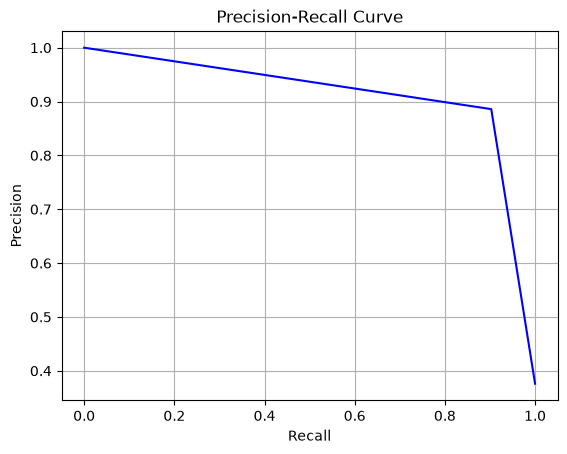

In [87]:
# Creating precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test,y_pred_test )

# Plot P-R Curve
plt.plot(recall, precision, color='blue')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()


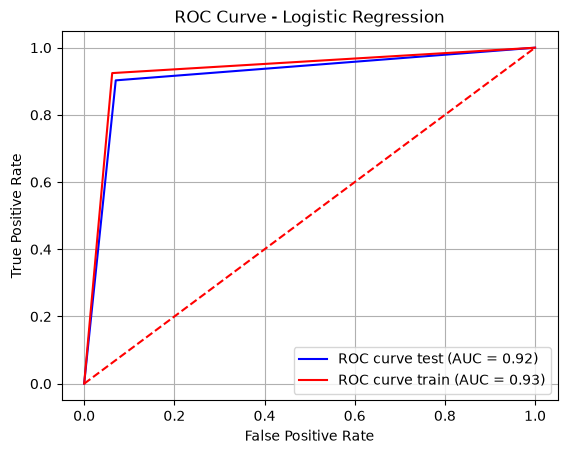

In [88]:

# Compute ROC curve for test data
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = auc(fpr, tpr)


# Compute ROC curve for train data
fpr1, tpr1, thresholds = roc_curve(y_train, y_pred_train)
roc_auc1 = auc(fpr1, tpr1) 

# Plot ROC curve
plt.plot(fpr, tpr, color='blue', label='ROC curve test (AUC = %0.2f)' % roc_auc)
plt.plot(fpr1, tpr1, color='red', label='ROC curve train (AUC = %0.2f)' % roc_auc1)


# Diagonal line (random model)
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()


In [94]:

# Get predicted probabilities for test data
y_prob_test = final_model.predict_proba(X_test)[:, 1]

# Define custom threshold
threshold = 0.4

# Convert probabilities to class labels
y_pred_test_costom = (y_prob_test >= threshold).astype(int)

# Evaluate
print(f'Classification report for test data:\n {classification_report(y_test, y_pred_test_costom)}')
print("Confusion Matrix for test data:\n", confusion_matrix(y_test, y_pred_test_costom))



# Get predicted probabilities for train data
y_prob_train = final_model.predict_proba(X_train)[:, 1]


# Convert probabilities to class labels
y_pred_train_custom = (y_prob_train >= threshold).astype(int)

from sklearn.metrics import confusion_matrix

cm_train =  confusion_matrix(y_train, y_pred_train_custom)
tn, fp, fn, tp = cm_train.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)



#Evaluate
print(f'\nClassification report for test data:\n{classification_report(y_train, y_pred_train_custom)}')
print("Confusion Matrix:\n", cm_train)

print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

Classification report for test data:
               precision    recall  f1-score   support

       False       0.94      0.93      0.94      1656
        True       0.89      0.90      0.89       998

    accuracy                           0.92      2654
   macro avg       0.91      0.92      0.91      2654
weighted avg       0.92      0.92      0.92      2654

Confusion Matrix for test data:
 [[1540  116]
 [  97  901]]

Classification report for test data:
              precision    recall  f1-score   support

       False       0.95      0.94      0.94      3795
        True       0.90      0.93      0.91      2395

    accuracy                           0.93      6190
   macro avg       0.93      0.93      0.93      6190
weighted avg       0.93      0.93      0.93      6190

Confusion Matrix:
 [[3559  236]
 [ 179 2216]]
Sensitivity (True Positive Rate): 0.9253
Specificity (True Negative Rate): 0.9378


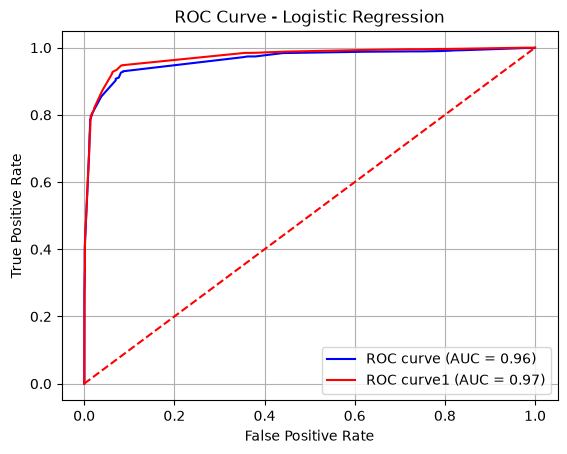

In [90]:

# Compute ROC curve for test data
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# Compute ROC curve for train data
fpr1, tpr1, thresholds = roc_curve(y_train, y_prob_train)
roc_auc1 = auc(fpr1, tpr1)

# Plot ROC curve
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot(fpr1, tpr1, color='red', label='ROC curve1 (AUC = %0.2f)' % roc_auc1)

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()
